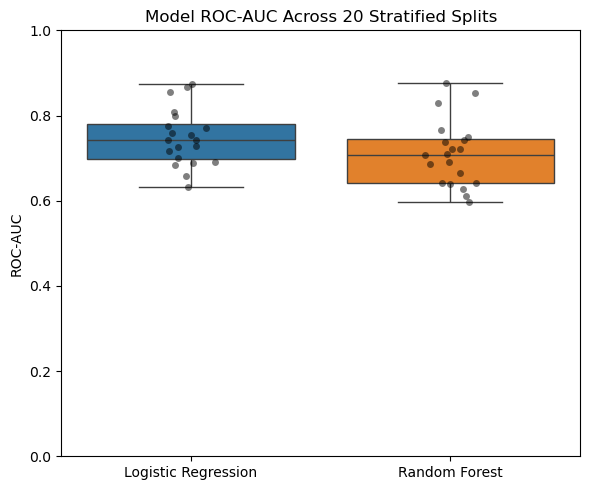


ROC-AUC Performance (Mean ± SD)
Logistic Regression: 0.749 ± 0.067
Random Forest: 0.711 ± 0.078


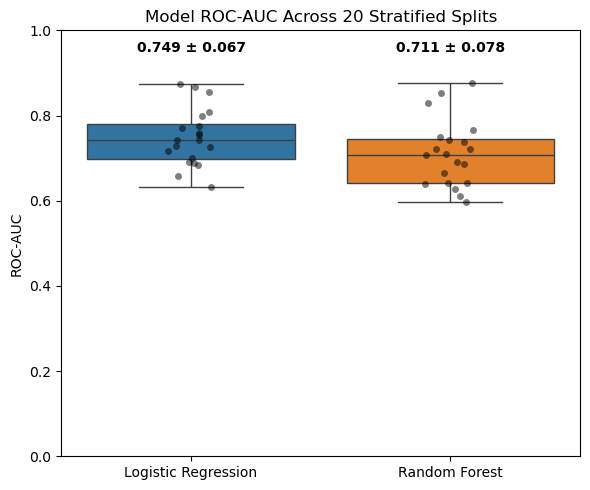


Permutation Feature Importance (ΔROC-AUC)

Logistic Regression
contact_length: 0.2430 ± 0.0515
contact_duration: 0.0318 ± 0.0288
area: -0.0164 ± 0.0251

Random Forest
contact_length: 0.1430 ± 0.0476
contact_duration: 0.0442 ± 0.0347
area: -0.0137 ± 0.0274
Explained variance ratio: [0.37813162 0.34224056]


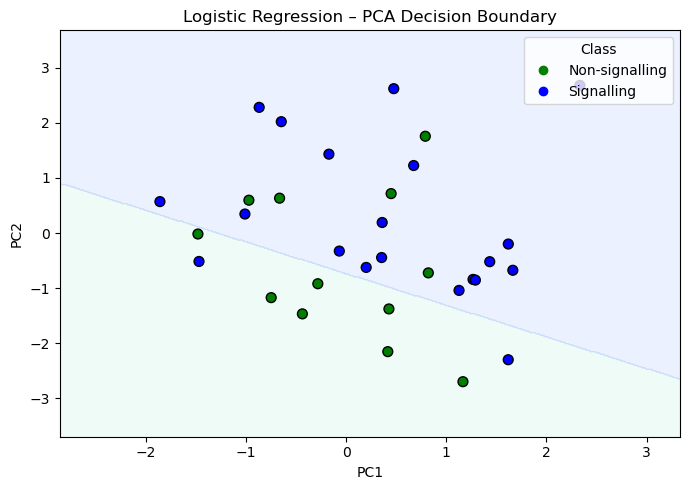

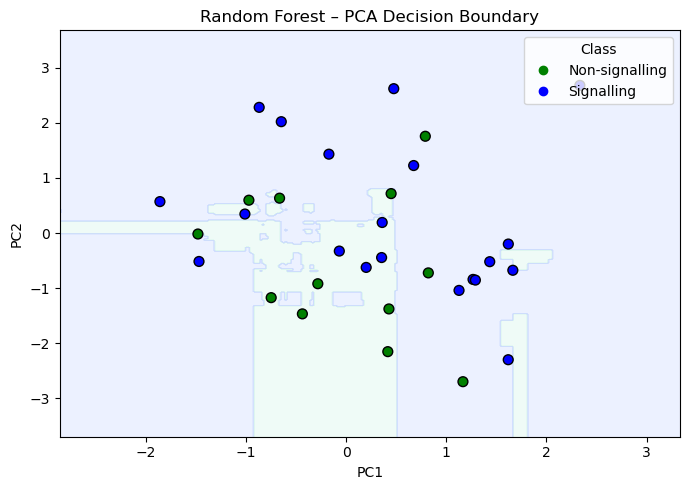

In [2]:
# Script for logistic regression and random forest multivariate models shown in Figure S2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

# 1. Load and clean data
df = pd.read_csv("CombinedMatrixPreWindowFirstSignFrameFINAL0925.csv")

df = df[['contact_length', 'contact_duration', 'area', 'signalling']]
df = df.dropna()
df = df[(df[['contact_length', 'contact_duration', 'area']] >= 0).all(axis=1)]

features = ["contact_length", "contact_duration", "area"]
X = df[features]
y = df["signalling"]


# 2. Define models
models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("Random Forest", RandomForestClassifier(random_state=42))
]

n_splits = 20

roc_storage = {name: [] for name, _ in models}
pfi_storage = {name: [] for name, _ in models}


# 3. Repeated training & ROC evaluation
for random_state in range(n_splits):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        stratify=y,
        random_state=random_state
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for model_name, model in models:

        model.fit(X_train_scaled, y_train)

        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_prob)

        roc_storage[model_name].append(auc)

        # ROC-based PFI
        pfi = permutation_importance(
            model,
            X_test_scaled,
            y_test,
            n_repeats=20,
            random_state=random_state,
            scoring="roc_auc"
        )

        pfi_storage[model_name].append(pfi.importances_mean)


# 4. ROC Boxplot
#roc_df = pd.DataFrame({
#    "Logistic Regression": roc_storage["Logistic Regression"],
#    "Random Forest": roc_storage["Random Forest"]
#})

#plt.figure(figsize=(6,5))
#sns.boxplot(data=roc_df)
#sns.stripplot(data=roc_df, color='black', alpha=0.5)

#plt.ylabel("ROC-AUC")
#plt.title("Model ROC-AUC Across 20 Stratified Splits")

# Force full ROC scale
#plt.ylim(0, 1)

#plt.tight_layout()
#plt.savefig("ROC_boxplot.pdf")
#plt.show()

# 4. ROC Boxplot + Mean ± SD
roc_df = pd.DataFrame({
    "Logistic Regression": roc_storage["Logistic Regression"],
    "Random Forest": roc_storage["Random Forest"]
})

# Compute mean and SD
roc_means = roc_df.mean()
roc_sds = roc_df.std()

print("\nROC-AUC Performance (Mean ± SD)")
for model in roc_df.columns:
    print(f"{model}: {roc_means[model]:.3f} ± {roc_sds[model]:.3f}")

plt.figure(figsize=(6,5))
sns.boxplot(data=roc_df)
sns.stripplot(data=roc_df, color='black', alpha=0.5)

# Add mean ± SD text above each box
for i, model in enumerate(roc_df.columns):
    mean = roc_means[model]
    sd = roc_sds[model]
    plt.text(i, 0.95, f"{mean:.3f} ± {sd:.3f}",
             ha='center', fontsize=10, fontweight='bold')

plt.ylabel("ROC-AUC")
plt.title("Model ROC-AUC Across 20 Stratified Splits")

# Force full ROC scale
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig("ROC_boxplot.pdf")
plt.show()


# 5. Aggregate PFI (Mean ± SD across splits)
pfi_mean = {}
pfi_sd = {}

for model_name, values in pfi_storage.items():
    values_array = np.array(values)  # shape: (n_splits, n_features)
    pfi_mean[model_name] = np.mean(values_array, axis=0)
    pfi_sd[model_name] = np.std(values_array, axis=0)

pfi_mean_df = pd.DataFrame(pfi_mean, index=features).T
pfi_sd_df = pd.DataFrame(pfi_sd, index=features).T

print("\nPermutation Feature Importance (ΔROC-AUC)")
for model in pfi_mean_df.index:
    print(f"\n{model}")
    for feature in features:
        mean = pfi_mean_df.loc[model, feature]
        sd = pfi_sd_df.loc[model, feature]
        print(f"{feature}: {mean:.4f} ± {sd:.4f}")


# 6. PCA Decision Boundary Plots
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=95,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

cmap_bg = ListedColormap(['#d2f4ea', '#c9d8ff'])
cmap_points = ListedColormap(['green', 'blue'])

x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

for model_name, model in models:

    model.fit(X_train_pca, y_train)

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7,5))
    plt.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg)

    scatter = plt.scatter(
        X_test_pca[:, 0],
        X_test_pca[:, 1],
        c=y_test,
        cmap=cmap_points,
        edgecolor='k',
        s=50
    )

    handles, labels = scatter.legend_elements()
    plt.legend(handles, ['Non-signalling', 'Signalling'],
               title="Class", loc='upper right')

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"{model_name} – PCA Decision Boundary")
    plt.tight_layout()

    plt.savefig(f"{model_name}_PCA_DecisionBoundary.pdf")
    plt.show()